In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data/29th June"  
OUTPUT_DIR = "."                    
TS = "hours_since_experiment_created"

# ---- Load data ----
co2_df    = pd.read_csv(f"{DATA_DIR}/co2_readings-Pulse_experiments-all_units-20260630185618.csv")
od_df     = pd.read_csv(f"{DATA_DIR}/od_readings-Pulse_experiments-all_units-20260630185618.csv")
nod_df    = pd.read_csv(f"{DATA_DIR}/od_readings_filtered-Pulse_experiments-all_units-20260630185618.csv")
gr_df     = pd.read_csv(f"{DATA_DIR}/growth_rates-Pulse_experiments-all_units-20260630185618.csv")
spec_df   = pd.read_csv(f"{DATA_DIR}/as7341_spectrum_readings-Pulse_experiments-all_units-20260630185618.csv")
dose_df   = pd.read_csv(f"{DATA_DIR}/dosing_events-Pulse_experiments-all_units-20260630185618.csv")

In [ ]:

# # ---- Discard specific dosing events ----
# # Sort chronologically first, then drop events by their 1-indexed position
# # in the overall dosing timeline (i.e. "1st line", "2nd line", etc. as drawn
# # left-to-right on the plot).
# dose_df = dose_df.sort_values(TS).reset_index(drop=True)
# EVENTS_TO_DISCARD = [1, 2, 7, 9]  # 1-indexed positions to drop
# drop_idx = [i - 1 for i in EVENTS_TO_DISCARD]
# dose_df = dose_df.drop(index=drop_idx).reset_index(drop=True)

In [9]:
# If multiple pioreactor units are present, restrict / loop as needed.
# Here we assume a single unit; adjust the filter below if you have more than one.
UNIT = co2_df["pioreactor_unit"].iloc[0]

In [10]:
co2_df  = co2_df[co2_df["pioreactor_unit"] == UNIT].sort_values(TS)
od_df   = od_df[od_df["pioreactor_unit"] == UNIT].sort_values(TS)
nod_df  = nod_df[nod_df["pioreactor_unit"] == UNIT].sort_values(TS)
gr_df   = gr_df[gr_df["pioreactor_unit"] == UNIT].sort_values(TS)
spec_df = spec_df[spec_df["pioreactor_unit"] == UNIT].sort_values(TS)
dose_df = dose_df[dose_df["pioreactor_unit"] == UNIT].sort_values(TS)

In [11]:
# AS7341 bands (nm)
BANDS = [415, 445, 480, 515, 555, 590, 630, 680]
BAND_COLORS = {
    415: "#7b2ff7", 445: "#3b5bdb", 480: "#1c7ed6", 515: "#0ca678",
    555: "#74b816", 590: "#f08c00", 630: "#e8590c", 680: "#c92a2a",
}

In [ ]:
# Dosing event style
DOSE_STYLES = {
    "add_media":     dict(color="tab:green",  linestyle="--", alpha=0.6),
    "add_alt_media": dict(color="tab:purple", linestyle="--", alpha=0.6),
    "remove_waste":  dict(color="tab:gray",   linestyle=":",  alpha=0.4),
}

def add_dosing_lines(ax, label_legend=False):
    """Overlay dosing event vertical lines on the given axis."""
    seen = set()
    for event_type, style in DOSE_STYLES.items():
        times = dose_df.loc[dose_df["event"] == event_type, TS]
        if times.empty:
            continue
        for t in times:
            ax.axvline(t, lw=0.8, **style,
                       label=event_type if (label_legend and event_type not in seen) else None)
            seen.add(event_type)



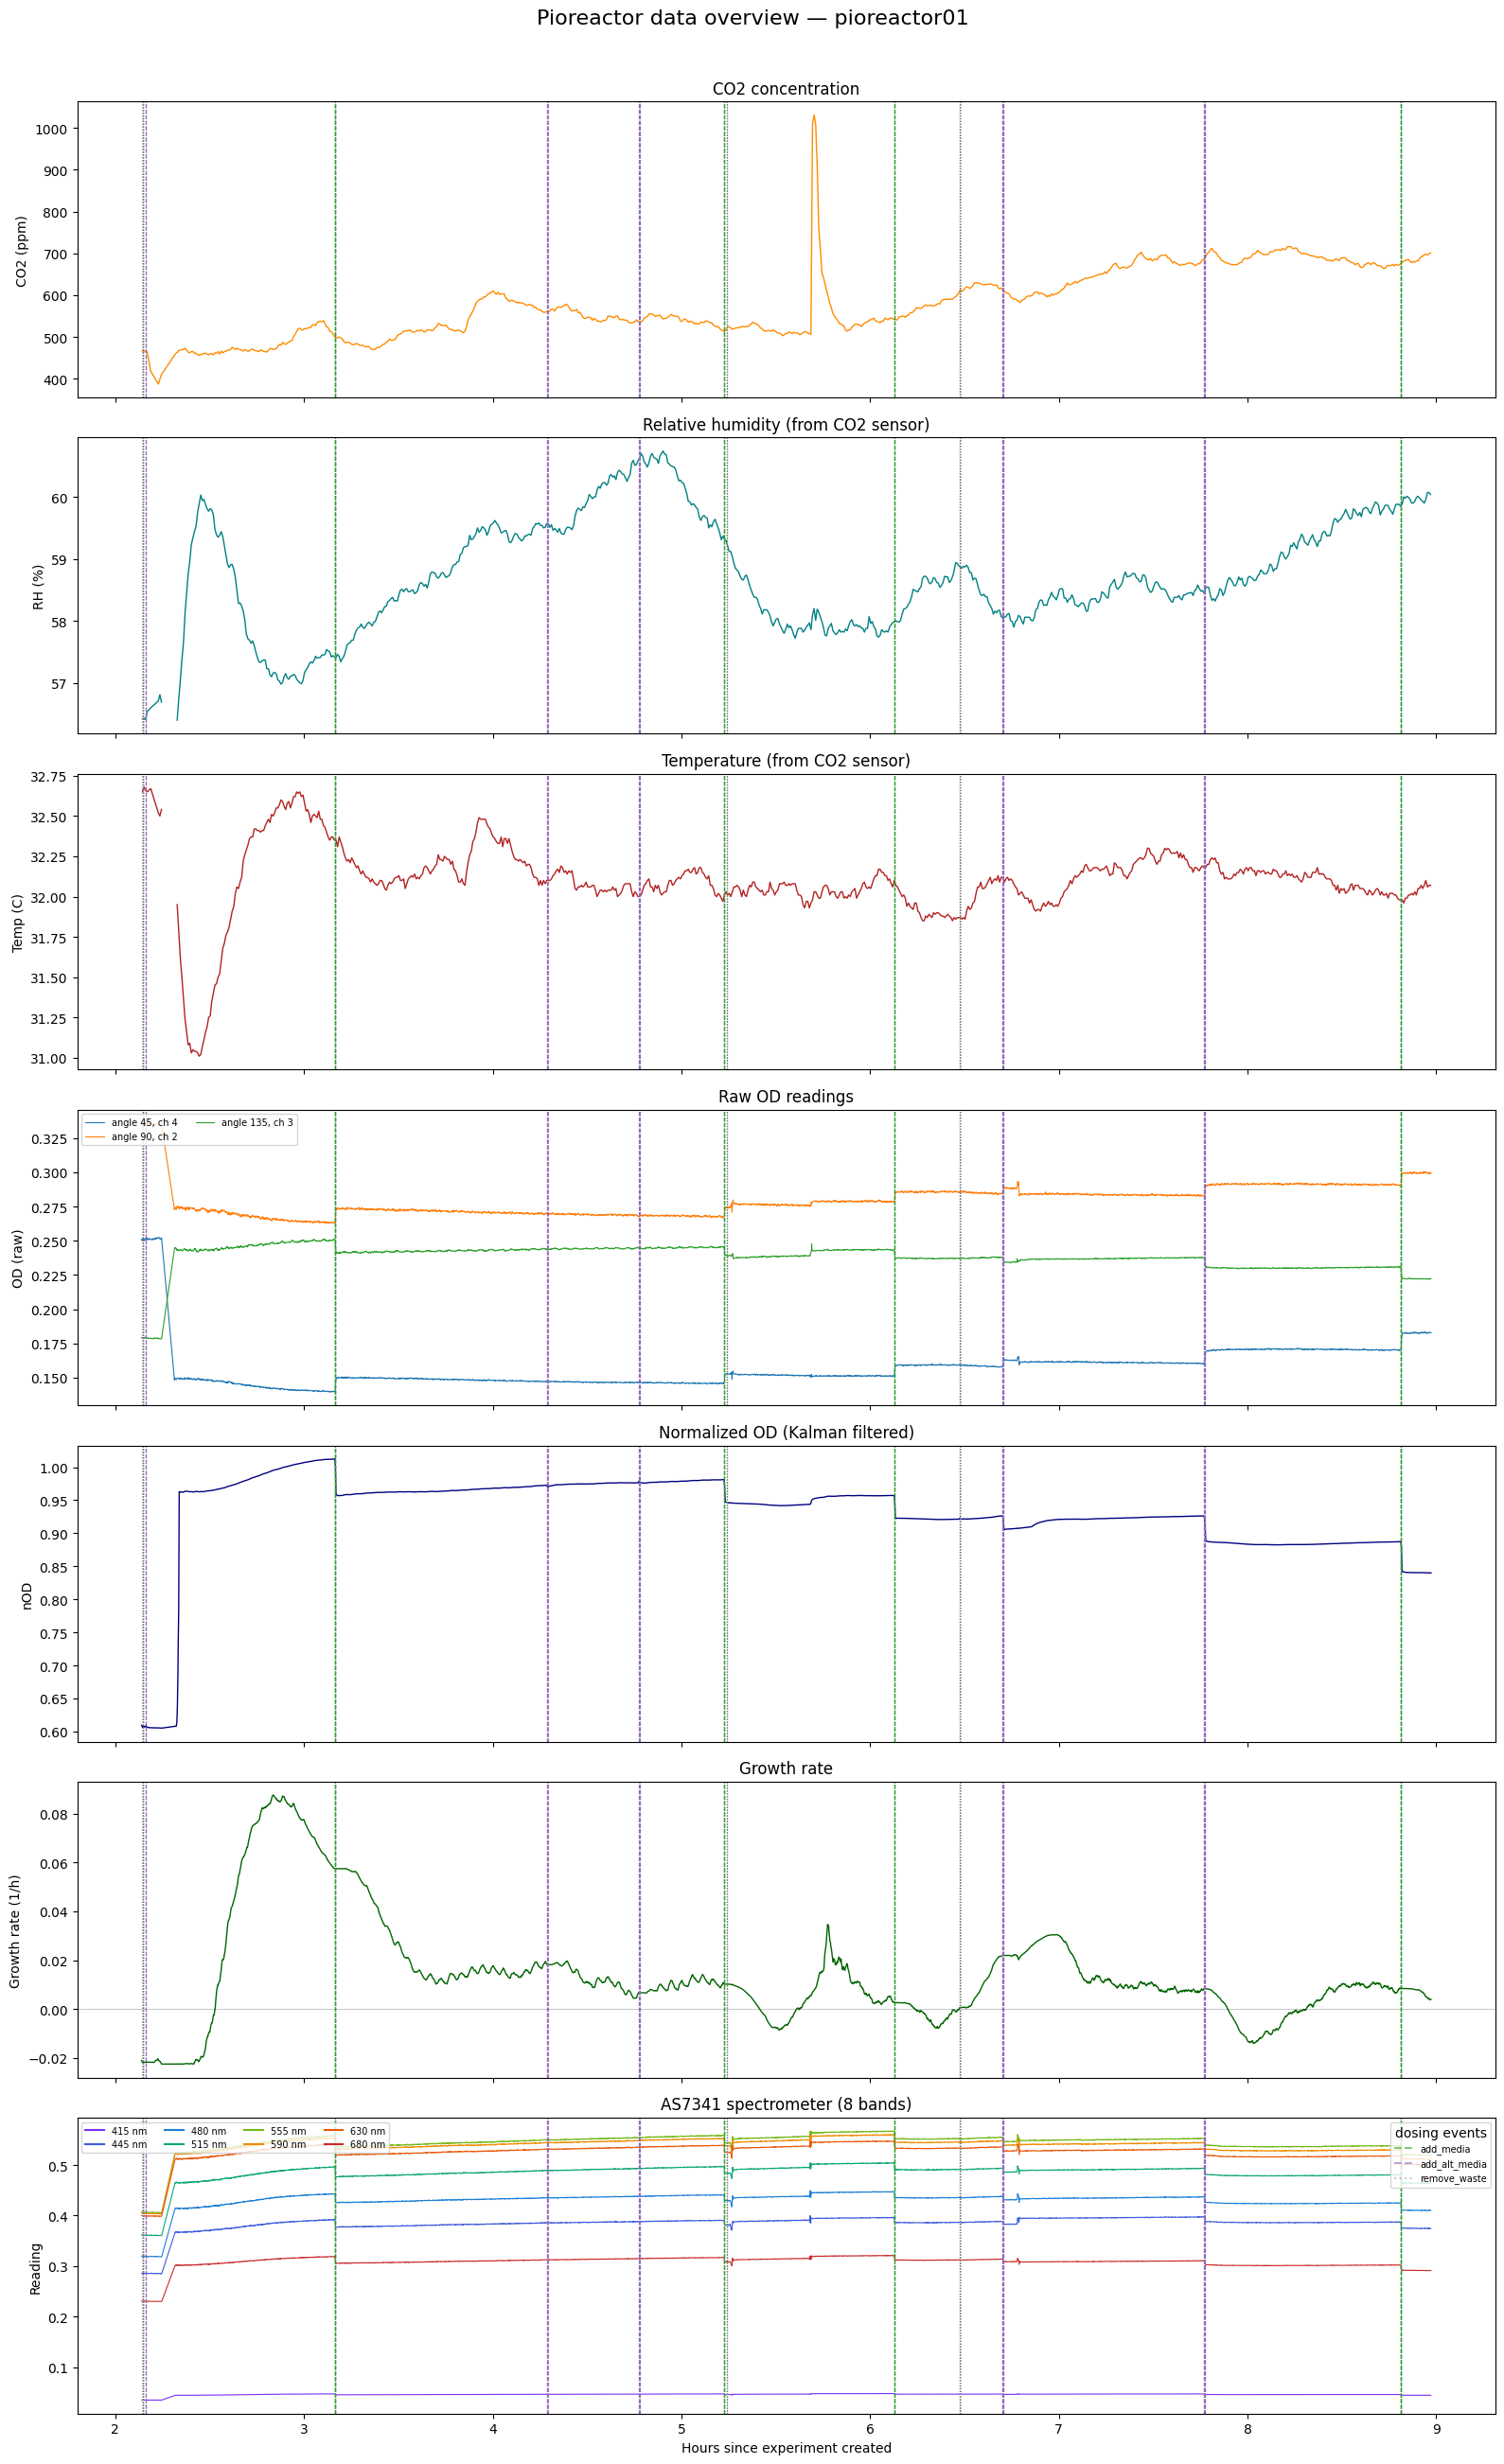

In [13]:
# ---- Figure layout: 7 rows ----
fig, axes = plt.subplots(7, 1, figsize=(16, 26), sharex=True)
(ax_co2, ax_rh, ax_temp, ax_od, ax_nod, ax_gr, ax_spec) = axes

# 1. CO2
ax_co2.plot(co2_df[TS], co2_df["co2_reading_ppm"], color="darkorange", lw=1)
ax_co2.set_ylabel("CO2 (ppm)")
ax_co2.set_title("CO2 concentration")
add_dosing_lines(ax_co2)

# 2. Relative humidity
ax_rh.plot(co2_df[TS], co2_df["relative_humidity"], color="teal", lw=1)
ax_rh.set_ylabel("RH (%)")
ax_rh.set_title("Relative humidity (from CO2 sensor)")
add_dosing_lines(ax_rh)

# 3. Temperature (from CO2 sensor)
ax_temp.plot(co2_df[TS], co2_df["temperature_c"], color="firebrick", lw=1)
ax_temp.set_ylabel("Temp (C)")
ax_temp.set_title("Temperature (from CO2 sensor)")
add_dosing_lines(ax_temp)

# 4. OD (raw) - plot each angle/channel separately
for (angle, channel), grp in od_df.groupby(["angle", "channel"]):
    ax_od.plot(grp[TS], grp["od_reading"], lw=0.8, label=f"angle {angle}, ch {channel}")
ax_od.set_ylabel("OD (raw)")
ax_od.set_title("Raw OD readings")
ax_od.legend(fontsize=7, loc="upper left", ncol=2)
add_dosing_lines(ax_od)

# 5. nOD (normalized/filtered)
ax_nod.plot(nod_df[TS], nod_df["normalized_od_reading"], color="navy", lw=1)
ax_nod.set_ylabel("nOD")
ax_nod.set_title("Normalized OD (Kalman filtered)")
add_dosing_lines(ax_nod)

# 6. Growth rate
ax_gr.plot(gr_df[TS], gr_df["rate"], color="darkgreen", lw=1)
ax_gr.axhline(0, color="black", lw=0.5, alpha=0.3)
ax_gr.set_ylabel("Growth rate (1/h)")
ax_gr.set_title("Growth rate")
add_dosing_lines(ax_gr)

# 7. Spectrometer - 8 bands
for band in BANDS:
    grp = spec_df[spec_df["band"] == band]
    ax_spec.plot(grp[TS], grp["reading"], lw=0.8,
                 color=BAND_COLORS[band], label=f"{band} nm")
ax_spec.set_ylabel("Reading")
ax_spec.set_title("AS7341 spectrometer (8 bands)")
add_dosing_lines(ax_spec)
handles_band = [plt.Line2D([0], [0], color=BAND_COLORS[b], lw=1.5, label=f"{b} nm") for b in BANDS]
ax_spec.legend(handles=handles_band, fontsize=7, loc="upper left", ncol=4)
dose_handles = [plt.Line2D([0], [0], **style, label=name) for name, style in DOSE_STYLES.items()
                if not dose_df[dose_df["event"] == name].empty]
if dose_handles:
    leg2 = ax_spec.legend(handles=dose_handles, fontsize=7, loc="upper right", title="dosing events")
    ax_spec.add_artist(leg2)
    ax_spec.legend(handles=handles_band, fontsize=7, loc="upper left", ncol=4)

ax_spec.set_xlabel("Hours since experiment created")

fig.suptitle(f"Pioreactor data overview — {UNIT}", fontsize=16, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.99])

fig.savefig(f"{OUTPUT_DIR}/pioreactor_overview.png", dpi=150, bbox_inches="tight")
plt.show()

### Annotated

           event  hours_since_experiment_created
1  add_alt_media                        2.162778
2      add_media                        3.164444
3  add_alt_media                        4.289167
4  add_alt_media                        4.773056
5      add_media                        5.226667
6      add_media                        6.127778
7  add_alt_media                        6.702222
8  add_alt_media                        7.770556
9      add_media                        8.812778


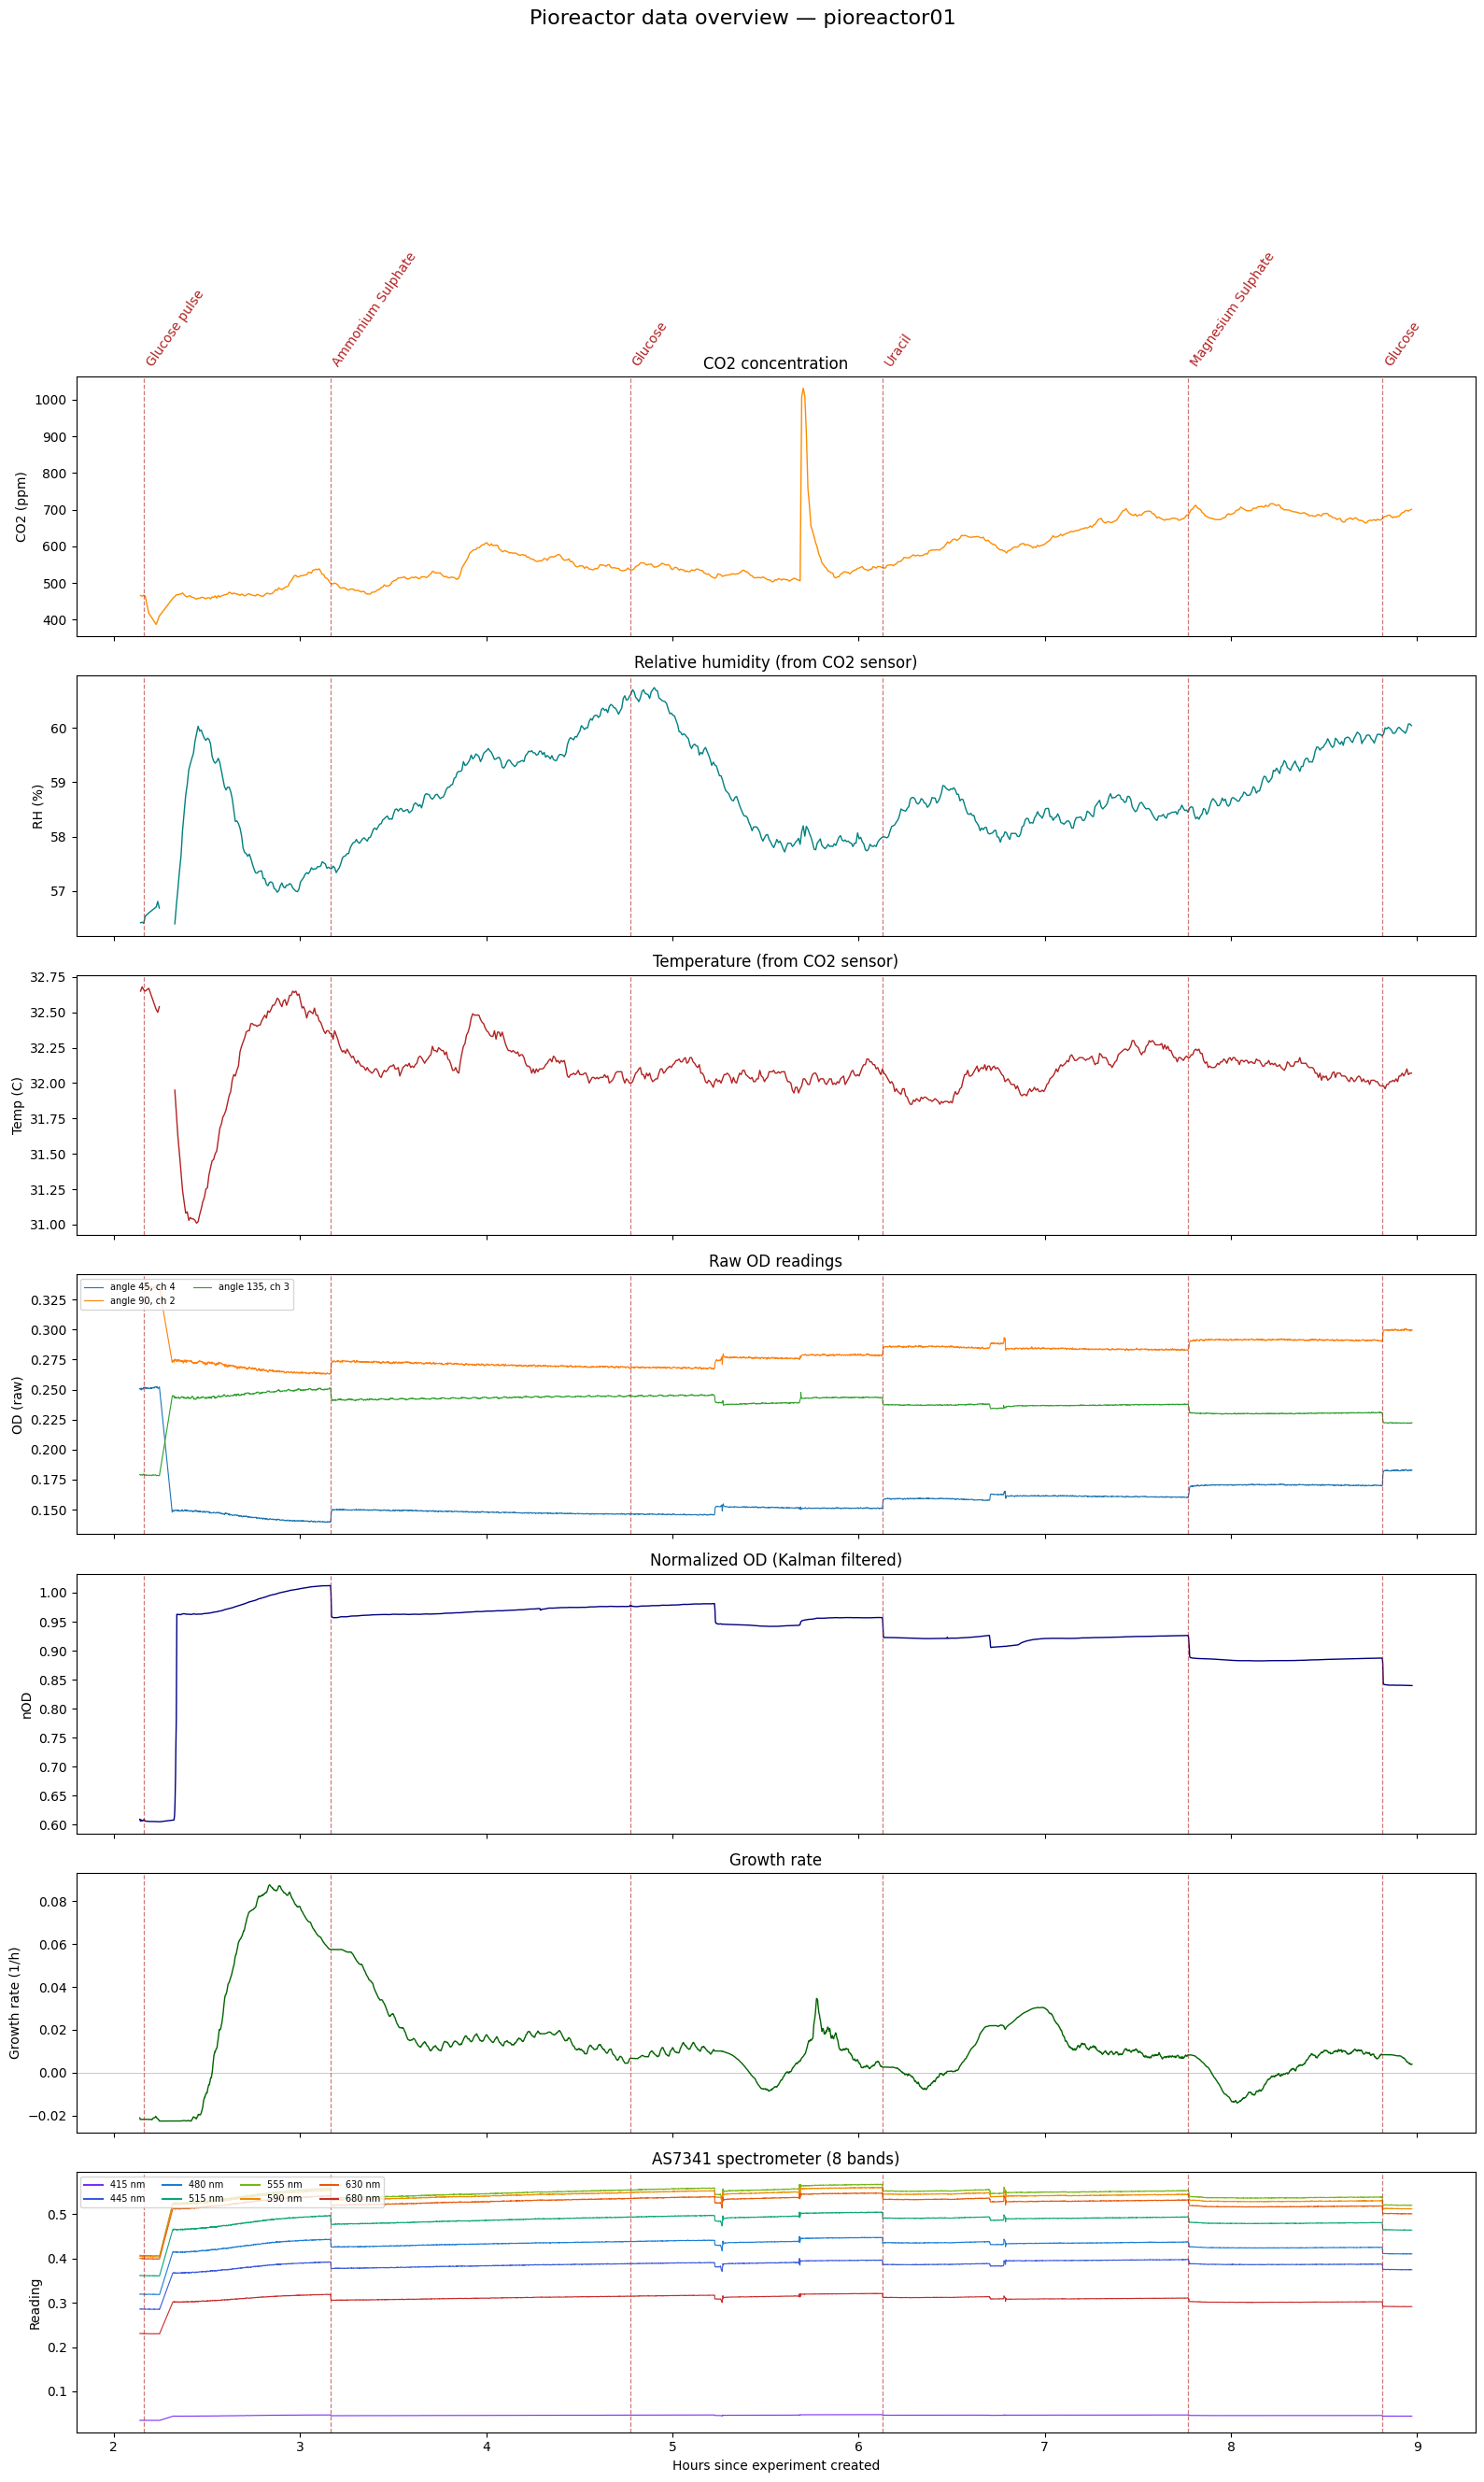

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import transforms

DATA_DIR = "./data/29th June"   
OUTPUT_DIR = "."                       
TS = "hours_since_experiment_created"

# ---- Load data ----
co2_df    = pd.read_csv(f"{DATA_DIR}/co2_readings-Pulse_experiments-all_units-20260630185618.csv")
od_df     = pd.read_csv(f"{DATA_DIR}/od_readings-Pulse_experiments-all_units-20260630185618.csv")
nod_df    = pd.read_csv(f"{DATA_DIR}/od_readings_filtered-Pulse_experiments-all_units-20260630185618.csv")
gr_df     = pd.read_csv(f"{DATA_DIR}/growth_rates-Pulse_experiments-all_units-20260630185618.csv")
spec_df   = pd.read_csv(f"{DATA_DIR}/as7341_spectrum_readings-Pulse_experiments-all_units-20260630185618.csv")
dose_df   = pd.read_csv(f"{DATA_DIR}/dosing_events-Pulse_experiments-all_units-20260630185618.csv")

# ---- Cluster dosing micro-pulses into single named additions ----
# Each "addition" (e.g. a glucose pulse) is logged as several individual
# add_media/add_alt_media rows fired within seconds of each other. We collapse
# each burst into one cluster (keeping its first timestamp for plotting) and
# drop routine remove_waste events entirely.
dose_df = dose_df.sort_values(TS).reset_index(drop=True)
meaningful = dose_df[dose_df["event"].isin(["add_media", "add_alt_media"])].copy()
gap = meaningful[TS].diff().fillna(999)
meaningful["cluster"] = (gap > 0.05).cumsum()  # new cluster if >3 min gap

clustered = (
    meaningful.groupby("cluster")
    .agg(event=("event", "first"), **{TS: (TS, "first")})
    .reset_index(drop=True)
)
clustered.index = clustered.index + 1  # 1-indexed cluster position

print(clustered)

EVENT_LABELS = {
    1: "Glucose pulse",
    2: "Ammonium Sulphate",
    #3: "Ammonium Sulphate",
    4: "Glucose",
    6: "Uracil",
    8: "Magnesium Sulphate",
    9: "Glucose",
}

dose_df = clustered.loc[clustered.index.isin(EVENT_LABELS.keys())].copy()
dose_df["label"] = dose_df.index.map(EVENT_LABELS)

# If multiple pioreactor units are present, restrict / loop as needed.
# Here we assume a single unit; adjust the filter below if you have more than one.
UNIT = co2_df["pioreactor_unit"].iloc[0]

co2_df  = co2_df[co2_df["pioreactor_unit"] == UNIT].sort_values(TS)
od_df   = od_df[od_df["pioreactor_unit"] == UNIT].sort_values(TS)
nod_df  = nod_df[nod_df["pioreactor_unit"] == UNIT].sort_values(TS)
gr_df   = gr_df[gr_df["pioreactor_unit"] == UNIT].sort_values(TS)
spec_df = spec_df[spec_df["pioreactor_unit"] == UNIT].sort_values(TS)
# dose_df already filtered/clustered above (single unit in this dataset)

# AS7341 bands (nm)
BANDS = [415, 445, 480, 515, 555, 590, 630, 680]
BAND_COLORS = {
    415: "#7b2ff7", 445: "#3b5bdb", 480: "#1c7ed6", 515: "#0ca678",
    555: "#74b816", 590: "#f08c00", 630: "#e8590c", 680: "#c92a2a",
}

# Dosing line style (all labeled events share one style now)
LINE_COLOR = "firebrick"

def add_dosing_lines(ax):
    """Draw a vertical line for each labeled dosing event."""
    for t in dose_df[TS]:
        ax.axvline(t, lw=0.9, color=LINE_COLOR, linestyle="--", alpha=0.6)

def add_dosing_labels(ax):
    """Annotate labeled dosing events with rotated text above the axis (top subplot only)."""
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    for t, label in zip(dose_df[TS], dose_df["label"]):
        ax.text(t, 1.03, label, transform=trans, rotation=55, color=LINE_COLOR,
                 fontsize=10, ha="left", va="bottom")

# ---- Figure layout: 7 rows ----
fig, axes = plt.subplots(7, 1, figsize=(16, 26), sharex=True)
(ax_co2, ax_rh, ax_temp, ax_od, ax_nod, ax_gr, ax_spec) = axes

# 1. CO2
ax_co2.plot(co2_df[TS], co2_df["co2_reading_ppm"], color="darkorange", lw=1)
ax_co2.set_ylabel("CO2 (ppm)")
ax_co2.set_title("CO2 concentration")
add_dosing_lines(ax_co2)
add_dosing_labels(ax_co2)  # text labels only on the top subplot

# 2. Relative humidity
ax_rh.plot(co2_df[TS], co2_df["relative_humidity"], color="teal", lw=1)
ax_rh.set_ylabel("RH (%)")
ax_rh.set_title("Relative humidity (from CO2 sensor)")
add_dosing_lines(ax_rh)

# 3. Temperature (from CO2 sensor)
ax_temp.plot(co2_df[TS], co2_df["temperature_c"], color="firebrick", lw=1)
ax_temp.set_ylabel("Temp (C)")
ax_temp.set_title("Temperature (from CO2 sensor)")
add_dosing_lines(ax_temp)

# 4. OD (raw) - plot each angle/channel separately
for (angle, channel), grp in od_df.groupby(["angle", "channel"]):
    ax_od.plot(grp[TS], grp["od_reading"], lw=0.8, label=f"angle {angle}, ch {channel}")
ax_od.set_ylabel("OD (raw)")
ax_od.set_title("Raw OD readings")
ax_od.legend(fontsize=7, loc="upper left", ncol=2)
add_dosing_lines(ax_od)

# 5. nOD (normalized/filtered)
ax_nod.plot(nod_df[TS], nod_df["normalized_od_reading"], color="navy", lw=1)
ax_nod.set_ylabel("nOD")
ax_nod.set_title("Normalized OD (Kalman filtered)")
add_dosing_lines(ax_nod)

# 6. Growth rate
ax_gr.plot(gr_df[TS], gr_df["rate"], color="darkgreen", lw=1)
ax_gr.axhline(0, color="black", lw=0.5, alpha=0.3)
ax_gr.set_ylabel("Growth rate (1/h)")
ax_gr.set_title("Growth rate")
add_dosing_lines(ax_gr)

# 7. Spectrometer - 8 bands
for band in BANDS:
    grp = spec_df[spec_df["band"] == band]
    ax_spec.plot(grp[TS], grp["reading"], lw=0.8,
                 color=BAND_COLORS[band], label=f"{band} nm")
ax_spec.set_ylabel("Reading")
ax_spec.set_title("AS7341 spectrometer (8 bands)")
add_dosing_lines(ax_spec)
handles_band = [plt.Line2D([0], [0], color=BAND_COLORS[b], lw=1.5, label=f"{b} nm") for b in BANDS]
ax_spec.legend(handles=handles_band, fontsize=7, loc="upper left", ncol=4)

ax_spec.set_xlabel("Hours since experiment created")

fig.suptitle(f"Pioreactor data overview — {UNIT}", fontsize=16, y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.94])

fig.savefig(f"{OUTPUT_DIR}/pioreactor_overview.png", dpi=150, bbox_inches="tight")
plt.show()